**프로젝트 목표 : 위성 데이터로부터 좌표를 추출하여 도로망을 형성하고 경로를 추천하는 시스템 구현**

구글 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
!pip install haversine

# 1단계 : 최단경로와 거리 계산하기
- 다익스트라 알고리즘 활용

In [ ]:
import heapq
from haversine import haversine

def read_coordinates_from_file(file_path):
    coordinates = {}
    with open(file_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(':')
            lat, lon = map(float, value.split(','))
            coordinates[key] = (lat, lon)
    return coordinates

def calculate_distance(coord1, coord2):
    return haversine(coord1, coord2)

def dijkstra(graph, start, end):
    distances = {node: (float('infinity'), None) for node in graph}
    distances[start] = (0, None)

    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_distance > distances[current_node][0]:
            continue

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor][0]:
                distances[neighbor] = (distance, current_node)
                heapq.heappush(priority_queue, (distance, neighbor))

    path = []
    current_node = end
    while current_node is not None:
        path.insert(0, current_node)
        current_node = distances[current_node][1]

    return path, distances[end][0]

if __name__ == "__main__":
    # 파일 경로를 입력으로 받기
    file_path = "/content/gdrive/MyDrive/위성데이터 (1)/Full Scene/K3A_20201124045546_31286_00069045_L1R_PS/1RCoordinate.txt"

    # 파일에서 좌표 정보를 읽기
    coordinates = read_coordinates_from_file(file_path)

    # 그래프를 생성
    graph = {}
    for key1, coord1 in coordinates.items():
        graph[key1] = {}
        for key2, coord2 in coordinates.items():
            if key1 != key2:
                distance = calculate_distance(coord1, coord2)
                graph[key1][key2] = distance

    # 출발지와 목적지 설정
    start_node = "CENTER"
    end_node = "BOTTOM_RIGHT"

    # 다익스트라 알고리즘 실행
    path, total_distance = dijkstra(graph, start_node, end_node)

    # 결과 출력
    print(f"Shortest path from {start_node} to {end_node}: {path}")
    print(f"Total distance: {total_distance} km")


Shortest path from CENTER to BOTTOM_RIGHT: ['CENTER', 'BOTTOM_RIGHT']
Total distance: 9.725708755312043 km


- 너비우선탐색알고리즘(BFS) 활용

In [ ]:
from collections import deque
from haversine import haversine

def read_coordinates_from_file(file_path):
    coordinates = {}
    with open(file_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(':')
            lat, lon = map(float, value.split(','))
            coordinates[key] = (lat, lon)
    return coordinates

def calculate_distance(coord1, coord2):
    return haversine(coord1, coord2)

def bfs(graph, start, end):
    visited = set()
    queue = deque([(start, [start])])

    while queue:
        current_node, path = queue.popleft()

        if current_node == end:
            return path

        if current_node not in visited:
            visited.add(current_node)

            for neighbor in graph[current_node]:
                if neighbor not in visited:
                    queue.append((neighbor, path + [neighbor]))

    return None

if __name__ == "__main__":
    # 파일 경로 입력
    file_path = "/content/gdrive/MyDrive/위성데이터 (1)/Full Scene/K3A_20201124045546_31286_00069045_L1R_PS/1RCoordinate.txt"

    # 파일에서 좌표 정보 읽기
    coordinates = read_coordinates_from_file(file_path)

    # 그래프를 생성
    graph = {}
    for key1, coord1 in coordinates.items():
        graph[key1] = set()
        for key2, coord2 in coordinates.items():
            if key1 != key2:
                distance = calculate_distance(coord1, coord2)
                if distance < 10:  # 예시로 거리가 10km 이하인 경우 연결
                    graph[key1].add(key2)

    # 출발지와 목적지를 설정
    start_node = "CENTER"
    end_node = "BOTTOM_RIGHT"

    # BFS 알고리즘을 실행
    path = bfs(graph, start_node, end_node)

    # 결과 출력
    if path:
        print(f"Shortest path from {start_node} to {end_node}: {path}")
        print(f"Total steps: {len(path) - 1}")
    else:
        print(f"No path found from {start_node} to {end_node}")


Shortest path from CENTER to BOTTOM_RIGHT: ['CENTER', 'BOTTOM_RIGHT']
Total steps: 1


# 2단계 : 위성 데이터의 좌표로부터 그래프 생성하기
- 위성 데이터의 좌표를 읽어와서 그래프를 생성
- 좌표 간의 거리는 하버사인 패키지를 사용하여 계산

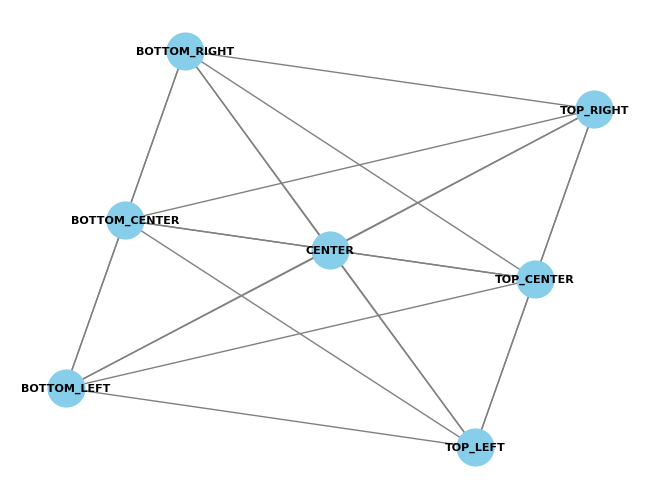

In [ ]:
import networkx as nx
from collections import deque
from haversine import haversine
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

def haversine(coord1, coord2):
    # 지구의 반경 (킬로미터 단위)
    R = 6371.0

    # 좌표에서 위도 및 경도 추출
    lat1, lon1 = radians(coord1[0]), radians(coord1[1])
    lat2, lon2 = radians(coord2[0]), radians(coord2[1])

    # 위도 및 경도 간의 차이 계산
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine 공식 적용
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    # 거리 계산
    distance = R * c

    return distance

def read_coordinates_from_file(file_path):
    coordinates = {}
    with open(file_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(':')
            lat, lon = map(float, value.split(','))
            coordinates[key] = (lat, lon)
    return coordinates

def create_graph(coordinates):
    graph = nx.Graph()

    for key1, coord1 in coordinates.items():
        for key2, coord2 in coordinates.items():
            if key1 != key2:
                distance = haversine(coord1, coord2)
                graph.add_edge(key1, key2, weight=distance)

    return graph

#파일 경로
file_path = "/content/gdrive/MyDrive/위성데이터/Full Scene/K3A_20201124045546_31286_00069045_L1R_PS/1RCoordinate.txt"

# 좌표 정보 읽기
coordinates = read_coordinates_from_file(file_path)

# 그래프 생성
graph = create_graph(coordinates)

# 시각화
pos = {node: coord for node, coord in coordinates.items()}
nx.draw(graph, pos, with_labels=True, node_size=700, node_color="skyblue", font_size=8, font_color="black", font_weight="bold", edge_color="gray", font_family="Arial")
plt.show()


# 3단계 : 가상 도로망을 기반으로 경로 탐색 및 최단거리 계산하기

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def haversine(coord1, coord2):
    # 지구의 반경 (킬로미터 단위)
    R = 6371.0

    # 좌표에서 위도 및 경도 추출
    lat1, lon1 = radians(coord1[0]), radians(coord1[1])
    lat2, lon2 = radians(coord2[0]), radians(coord2[1])

    # 위도 및 경도 간의 차이 계산
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine 공식 적용
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    # 거리 계산
    distance = R * c

    return distance

def read_coordinates_from_file(file_path):
    coordinates = {}
    with open(file_path, 'r') as file:
        for line in file:
            key, value = line.strip().split(':')
            lat, lon = map(float, value.split(','))
            coordinates[key] = (lat, lon)
    return coordinates

def create_graph(coordinates):
    graph = nx.Graph()

    for key1, coord1 in coordinates.items():
        for key2, coord2 in coordinates.items():
            if key1 != key2:
                distance = haversine(coord1, coord2)
                graph.add_edge(key1, key2, weight=distance)

    return graph

def dijkstra(graph, start, end):
    path = nx.shortest_path(graph, source=start, target=end, weight='weight')
    total_distance = nx.shortest_path_length(graph, source=start, target=end, weight='weight')
    return path, total_distance

def bfs(graph, start, end):
    path = nx.shortest_path(graph, source=start, target=end, weight='weight')
    total_distance = nx.shortest_path_length(graph, source=start, target=end, weight='weight')
    return path, total_distance

# 파일 경로
file_path = "/content/gdrive/MyDrive/위성데이터/Full Scene/K3A_20201124045546_31286_00069045_L1R_PS/1RCoordinate.txt"

# 좌표 정보 읽어오기
coordinates = read_coordinates_from_file(file_path)

# 그래프 생성
graph = create_graph(coordinates)

# 다익스트라 알고리즘
start_node = "CENTER"
end_node = "TOP_LEFT"
path_dijkstra, total_distance_dijkstra = dijkstra(graph, start_node, end_node)

print(f"Dijkstra Algorithm: {path_dijkstra} / Total Distance: {total_distance_dijkstra:.2f} km")

# 너비 우선 탐색 알고리즘
path_bfs, total_distance_bfs = bfs(graph, start_node, end_node)

print(f"BFS Algorithm: {path_bfs} / Total Distance: {total_distance_bfs:.2f} km")


Dijkstra Algorithm: ['CENTER', 'TOP_LEFT'] / Total Distance: 9.68 km
BFS Algorithm: ['CENTER', 'TOP_LEFT'] / Total Distance: 9.68 km
